# Oasis Infobyte Internship

## Data Analytics

### Task 2 - Customer Segmentation Analysis

**Objective:**
To segment customers based on their purchasing behavior using K-Means clustering and provide business insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')
%matplotlib inline

In [3]:
from google.colab import files

uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [4]:
df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 34335


In [8]:
# Remove rows where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

# Remove duplicate rows
df = df.drop_duplicates()

# Check the dataset again
print(df.shape)
df.isnull().sum()

(797885, 8)


,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['TotalAmount'] = df['Quantity'] * df['Price']

In [11]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,17,-51.74
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000
mean,202.908617,7.552339,2741.499712
std,211.857936,15.972262,13676.639629
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,321.065000
50%,96.000000,4.000000,822.010000
75%,381.000000,8.000000,2142.195000
max,739.000000,510.000000,570380.610000


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

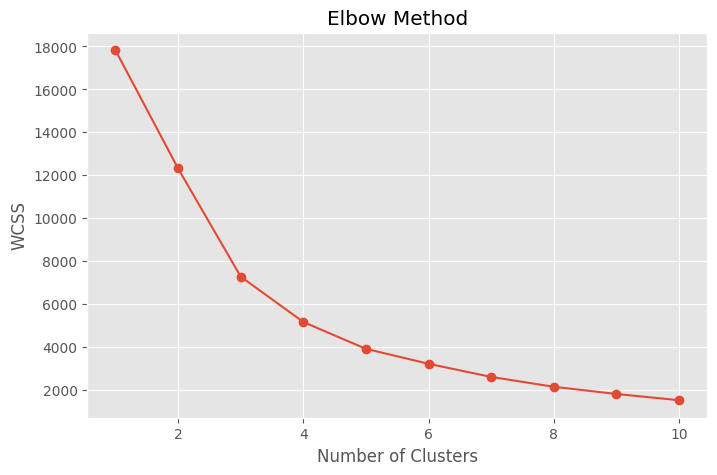

In [15]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,17,-51.74,0
12347.0,2,8,4921.53,1
12348.0,75,5,2019.40,1
12349.0,19,5,4404.54,1
12350.0,310,1,334.40,0


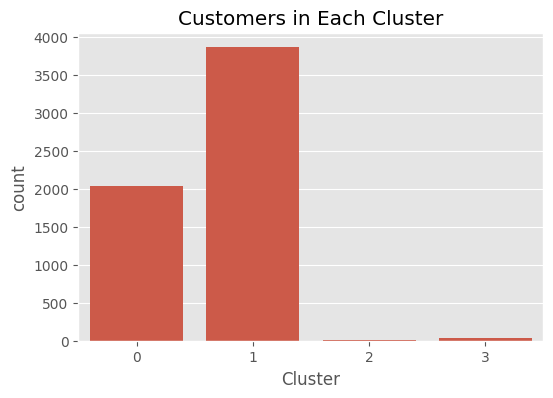

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Cluster', data=rfm)

plt.title("Customers in Each Cluster")
plt.show()

In [18]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,466.260187,2.579283,606.487861
1,66.092770,8.688261,2749.896282
2,3.500000,257.250000,413886.007500
3,20.119048,120.595238,66361.469833


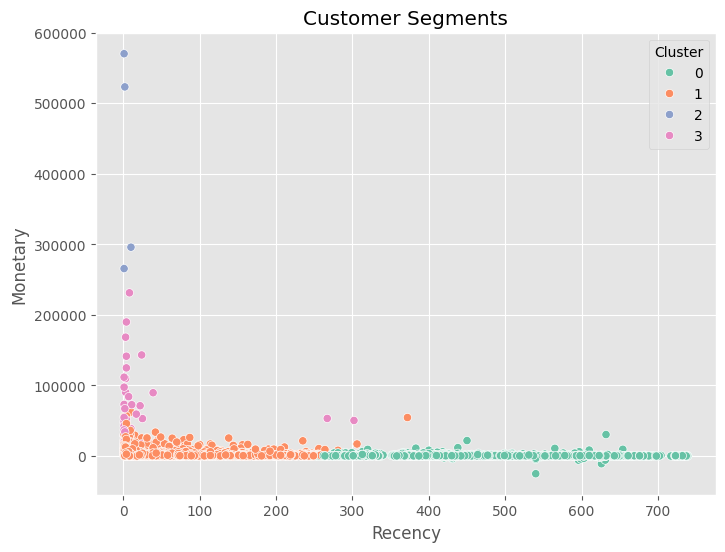

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

# Business Recommendations

- Reward high-value customers with loyalty programs.
- Re-engage inactive customers using discounts and special offers.
- Focus marketing efforts on frequent buyers.
- Encourage low-frequency customers to make repeat purchases.
- Monitor customer segments regularly to improve retention and sales.

# Conclusion

Customer Segmentation was successfully performed using the K-Means clustering algorithm.

### Key Findings
- Customers were divided into four meaningful clusters.
- RFM (Recency, Frequency, Monetary) analysis helped identify purchasing behavior.
- High-value customers can be targeted with premium offers.
- Low-engagement customers can be reactivated through personalized campaigns.

This analysis helps businesses improve customer retention, marketing strategies, and overall profitability.